# 04｜CNN 组件对比：Pooling 改变了什么？

本页只替换 Pooling，其余数据划分、随机种子、通道数、卷积核、学习率和 Epoch 保持一致。

In [1]:
%matplotlib inline
from pathlib import Path
import sys

LAB_DIR = Path.cwd()
if not (LAB_DIR / "cnn_lab").is_dir():
    LAB_DIR = (LAB_DIR / "02_cnn_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

from cnn_lab import compare_pooling

## 运行前先预测

比较 Max Pooling、Average Pooling 和不使用 Pooling。不要只预测谁的 Accuracy 最高，还要预测：

- 哪个模型参数更多？
- 哪个模型保留的空间尺寸更大？
- 图片右移 1 像素后，结果是否同样稳定？

不使用 Pooling 会让分类层接收更大的特征图，因此参数量变化也是实验结果的一部分。


CNN 配置对比
------------------------------------------------------------------------------
配置                           测试准确率       右移准确率         参数量       耗时(秒)
------------------------------------------------------------------------------
Max Pooling                 96.7%      65.6%       3,818        0.35
Average Pooling             96.0%      52.7%       3,818        0.31
不使用 Pooling                 97.3%      51.1%      11,498        0.39
------------------------------------------------------------------------------


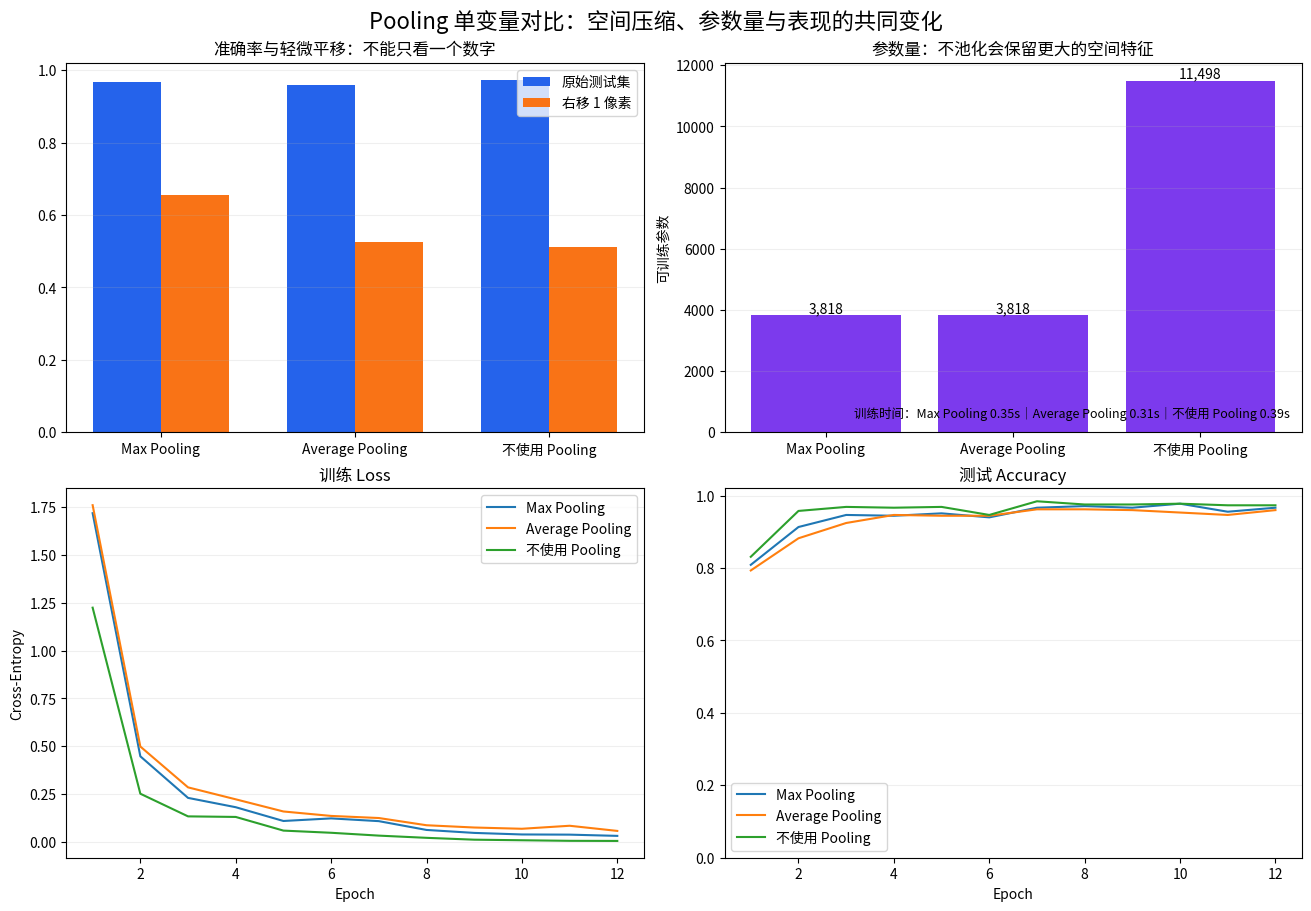

In [2]:
DEVICE = "cpu"
# 使用第 x 块 GPU 时改为 DEVICE = "cuda:x"，并把 x 替换为课堂指定编号。

pooling_results = compare_pooling(epochs=12, device=DEVICE)

## 结论模板

> 本次只修改了 Pooling。图中显示 ______ 的空间压缩和参数量为 ______；在原始/右移测试集上表现为 ______。在当前数据、模型和随机种子下，这支持 ______，但不能推出某种 Pooling 永远更好。

三种配置的参数量并不相同，所以这不是严格的同参数预算竞赛，而是结构代价实验。

## 完成本页后：释放资源并结束内核

运行下面的最后一个单元格。它会依次清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后，VS Code 可能显示“内核已停止”“请选择内核”或暂时断开连接，这是正常现象，表示当前 Notebook 的 Python 进程已经结束。再次实验时，重新选择 Python 内核即可。

In [3]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

# 先释放当前进程中未使用的 CUDA 缓存。
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")

# 正常关闭当前 Jupyter 内核；再次运行时需要重新选择内核。
get_ipython().kernel.do_shutdown(restart=False)


清理完成，正在结束当前 Notebook 的 Python 内核……


{'status': 'ok', 'restart': False}